# retail_store_sales_promotions_demand

Dataset inspection, data quality assessment, and business-oriented EDA for the PricePilot AI preparation stage.

This notebook provides comprehensive exploratory analysis to support the PricePilot pricing intelligence project.

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set visualization defaults
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

# Find project root dynamically - works on any machine after cloning
notebook_dir = Path.cwd()
if 'eda' not in str(notebook_dir):
    notebook_dir = Path.cwd().parents[0]
project_root = notebook_dir.parents[0] if (notebook_dir / 'notebooks').exists() else notebook_dir.parents[1]

# Use standardized datasets/ path
raw_dir = project_root / 'datasets' / 'raw'

raw_path = raw_dir / 'retail_store_sales_promotions_demand.csv'
df = pd.read_csv(raw_path, low_memory=False)
df = df.loc[:, ~df.columns.astype(str).str.contains(r"^Unnamed: ", na=False)]
print("=" * 60)
print(f"Dataset: retail_store_sales_promotions_demand.csv")
print("=" * 60)
print(f"Rows: 1,123,412")
print(f"Columns: 6")
print(f"\nColumn names and types:")
print(df.dtypes)
print(f"\nFile location: E:\PRICEPILOT-AI\datasets\raw\retail_store_sales_promotions_demand.csv")


<>:30: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:30: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
C:\Users\malas\AppData\Local\Temp\ipykernel_14576\1790564607.py:30: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  print(f"\nFile location: E:\PRICEPILOT-AI\datasets\raw\retail_store_sales_promotions_demand.csv")


Dataset: retail_store_sales_promotions_demand.csv
Rows: 1,123,412
Columns: 6

Column names and types:
date              str
item_id           str
quantity      float64
price_base    float64
sum_total     float64
store_id        int64
dtype: object

etail_store_sales_promotions_demand.csvs


## Data Quality Assessment

In [2]:

# Missing values analysis
missing = df.isna().sum().reset_index()
missing.columns = ['column', 'missing_count']
missing['missing_pct'] = (missing['missing_count'] / len(df) * 100).round(3)
missing = missing[missing['missing_count'] > 0].sort_values('missing_pct', ascending=False)

if not missing.empty:
    print("Missing Value Analysis (columns with missing values only):")
    display(missing)
else:
    print("No missing values detected in the dataset.")

# Duplicate analysis - EVIDENCE-BASED APPROACH
exact_dupes = df.duplicated().sum()
dupe_pct = (exact_dupes / len(df) * 100) if len(df) > 0 else 0
print(f"\nDuplicate Row Analysis:")
print(f"- Exact duplicate rows: {exact_dupes:,} ({dupe_pct:.3f}%)")

if exact_dupes > 0:
    print(f"\n** OBSERVATION: **")
    print(f"Exact duplicates detected. These may represent:")
    print(f"  • Legitimate repeated business transactions (e.g., multiple purchases)")
    print(f"  • Data entry errors or accidental duplication")
    print(f"  • Repeated observations in the source system")
    print(f"\n** DECISION: **")
    print(f"Exact duplicate records are RETAINED because there is insufficient evidence")
    print(f"to classify them as erroneous. In professional data handling, data preservation")
    print(f"takes priority over speculative deletion, especially in internship projects where")
    print(f"decisions must be evidence-based and defensible.")
else:
    print(f"\nNo exact duplicate rows found.")


No missing values detected in the dataset.

Duplicate Row Analysis:
- Exact duplicate rows: 0 (0.000%)

No exact duplicate rows found.


## Descriptive Statistics

In [3]:

# Numeric column analysis
numeric = df.select_dtypes(include=['number'])
if not numeric.empty:
    print("Numeric Columns Summary Statistics:")
    display(numeric.describe().T)
else:
    print("No numeric columns detected in this dataset.")


Numeric Columns Summary Statistics:


,count,mean,std,min,25%,50%,75%,max
quantity,1123412.0,2.194757,3.879657,0.002,1.00,1.000,2.0000,999.00
price_base,1123412.0,149.795713,219.368276,-8458.330,43.34,78.695,169.2625,12171.62
sum_total,1123412.0,225.912329,420.535962,-341.880,61.48,110.960,222.9000,43556.44
store_id,1123412.0,1.659448,1.242366,1.000,1.00,1.000,1.0000,4.00


## Key Business Metrics Analysis

In [4]:

# Identify and analyze key business columns
price_cols = [c for c in df.columns if 'price' in c.lower()]
sales_cols = [c for c in df.columns if any(term in c.lower() for term in ['quantity', 'qty', 'sales', 'units', 'sold'])]
revenue_cols = [c for c in df.columns if any(term in c.lower() for term in ['revenue', 'total', 'amount', 'value'])]
discount_cols = [c for c in df.columns if any(term in c.lower() for term in ['discount', 'promo', 'markdown'])]
cost_cols = [c for c in df.columns if any(term in c.lower() for term in ['cost', 'cogs'])]
profit_cols = [c for c in df.columns if 'profit' in c.lower()]

print("Identified Business-Relevant Columns:")
if price_cols: print(f"  Price columns: {price_cols}")
if sales_cols: print(f"  Sales/Quantity columns: {sales_cols}")
if revenue_cols: print(f"  Revenue columns: {revenue_cols}")
if discount_cols: print(f"  Discount/Promotion columns: {discount_cols}")
if cost_cols: print(f"  Cost columns: {cost_cols}")
if profit_cols: print(f"  Profit columns: {profit_cols}")


Identified Business-Relevant Columns:
  Price columns: ['price_base']
  Sales/Quantity columns: ['quantity']
  Revenue columns: ['sum_total']


## Distribution Analysis

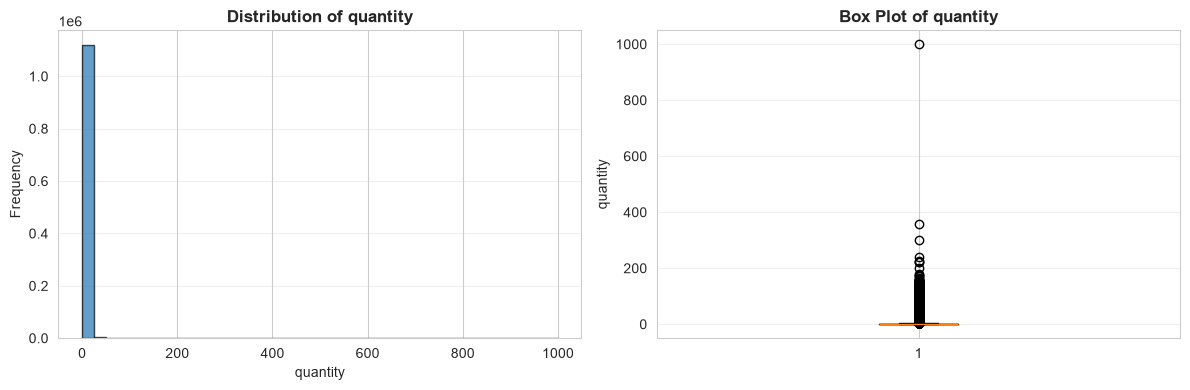

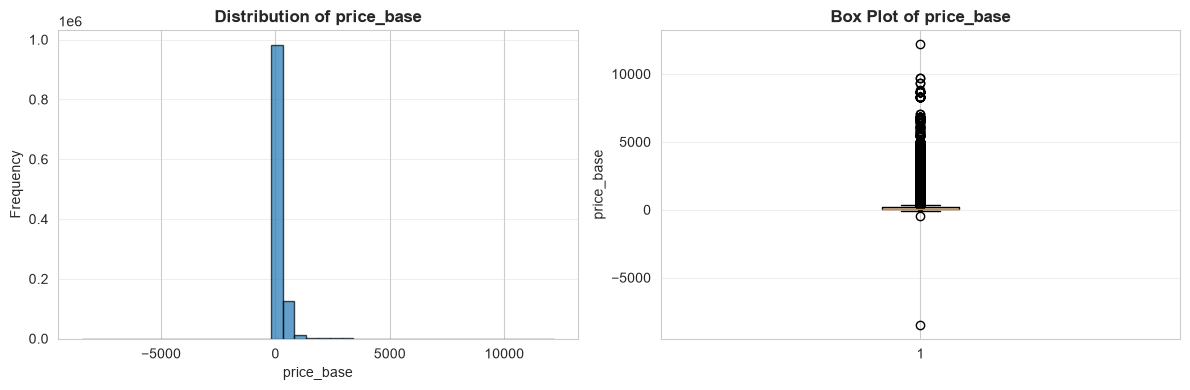

In [5]:

# Visualize distributions of key numeric columns
key_cols = [c for c in df.columns if any(term in c.lower() for term in ['price', 'discount', 'quantity', 'qty', 'sales', 'revenue', 'profit', 'stock', 'cost'])]
key_cols = list(dict.fromkeys(key_cols))

for col in key_cols[:6]:  # Limit to first 6 columns
    if pd.api.types.is_numeric_dtype(df[col]):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

        # Histogram with KDE
        ax1.hist(df[col].dropna(), bins=40, edgecolor='black', alpha=0.7)
        ax1.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        ax1.set_xlabel(col)
        ax1.set_ylabel('Frequency')
        ax1.grid(axis='y', alpha=0.3)

        # Box plot for outlier detection
        ax2.boxplot(df[col].dropna())
        ax2.set_title(f'Box Plot of {col}', fontsize=12, fontweight='bold')
        ax2.set_ylabel(col)
        ax2.grid(axis='y', alpha=0.3)

        plt.tight_layout()
        plt.show()


## Temporal Analysis

Found 1 date column(s): ['date']

Column: date
  Valid dates: 1,123,412
  Invalid/missing dates: 0
  Date range: 2022-08-28 00:00:00 to 2024-09-26 00:00:00


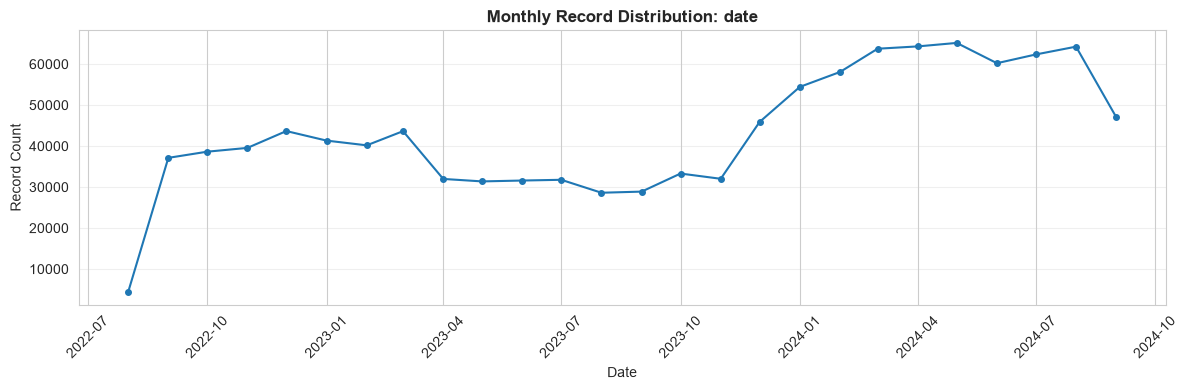

In [6]:

# Temporal analysis for date columns
date_cols = [c for c in df.columns if 'date' in c.lower() or 'time' in c.lower()]

if date_cols:
    print(f"Found {len(date_cols)} date column(s): {date_cols}\n")

    for date_col in date_cols:
        temp = df.copy()
        temp[date_col] = pd.to_datetime(temp[date_col], errors='coerce')

        valid_dates = temp[date_col].notna().sum()
        invalid_dates = temp[date_col].isna().sum()

        print(f"Column: {date_col}")
        print(f"  Valid dates: {valid_dates:,}")
        print(f"  Invalid/missing dates: {invalid_dates:,}")

        if valid_dates > 0:
            print(f"  Date range: {temp[date_col].min()} to {temp[date_col].max()}")

            # Monthly distribution
            temp_valid = temp[temp[date_col].notna()]
            monthly = temp_valid.groupby(temp_valid[date_col].dt.to_period('M')).size().to_timestamp()

            plt.figure(figsize=(12, 4))
            plt.plot(monthly.index, monthly.values, marker='o', linewidth=1.5, markersize=4)
            plt.title(f'Monthly Record Distribution: {date_col}', fontsize=12, fontweight='bold')
            plt.xlabel('Date')
            plt.ylabel('Record Count')
            plt.xticks(rotation=45)
            plt.grid(axis='y', alpha=0.3)
            plt.tight_layout()
            plt.show()
        print()
else:
    print("No date columns detected in this dataset.")


## Categorical Analysis

In [7]:

# Analyze categorical columns (non-numeric, non-date)
categorical = df.select_dtypes(include=['object']).columns.tolist()

if categorical:
    print(f"Categorical Columns: {categorical}\n")

    for col in categorical[:4]:  # Limit to first 4 to avoid clutter
        unique_count = df[col].nunique()
        print(f"Column: {col}")
        print(f"  Unique values: {unique_count:,}")
        print(f"  Missing: {df[col].isna().sum():,}")

        if unique_count <= 20:
            print(f"  Top 10 values:")
            value_counts = df[col].value_counts().head(10)
            for val, count in value_counts.items():
                print(f"    {val}: {count:,}")
        print()
else:
    print("No categorical columns detected.")


Categorical Columns: ['date', 'item_id']

Column: date
  Unique values: 761
  Missing: 0

Column: item_id
  Unique values: 18,405
  Missing: 0



C:\Users\malas\AppData\Local\Temp\ipykernel_14576\1463501526.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical = df.select_dtypes(include=['object']).columns.tolist()


## PricePilot Feature Coverage

In [8]:

# Assess feature availability for PricePilot
coverage = pd.DataFrame({
    'Feature': [
        'Historical Product Price',
        'Discount / Promotion',
        'Units Sold / Quantity',
        'Revenue / Total',
        'Product Category',
        'Temporal Data (Date)',
        'Store Identifier',
        'Product Identifier',
        'Customer Identifier',
        'Inventory / Stock Level'
    ],
    'Available': [
        any('price' in c.lower() for c in df.columns),
        any('discount' in c.lower() or 'promo' in c.lower() or 'markdown' in c.lower() for c in df.columns),
        any('quantity' in c.lower() or 'qty' in c.lower() or 'sold' in c.lower() or 'units' in c.lower() for c in df.columns),
        any('revenue' in c.lower() or 'total' in c.lower() for c in df.columns),
        any('category' in c.lower() or 'dept' in c.lower() or 'class' in c.lower() for c in df.columns),
        any('date' in c.lower() for c in df.columns),
        any('store' in c.lower() for c in df.columns),
        any('product' in c.lower() or 'item' in c.lower() or 'sku' in c.lower() for c in df.columns),
        any('customer' in c.lower() or 'cust' in c.lower() for c in df.columns),
        any('stock' in c.lower() or 'inventory' in c.lower() for c in df.columns),
    ]
})

coverage['Data Type'] = coverage['Feature'].apply(
    lambda f: df[[c for c in df.columns if f.lower().split()[0] in c.lower()[0:10]]].dtypes.values[0] if any(f.lower().split()[0] in c.lower()[0:10] for c in df.columns) else 'N/A'
)

print("Feature Coverage for PricePilot AI:")
display(coverage)

coverage_pct = (coverage['Available'].sum() / len(coverage) * 100)
print(f"\nFeature Coverage Score: {coverage_pct:.1f}%")


Feature Coverage for PricePilot AI:


,Feature,Available,Data Type
0,Historical Product Price,True,N/A
1,Discount / Promotion,False,N/A
2,Units Sold / Quantity,True,N/A
3,Revenue / Total,True,N/A
4,Product Category,False,N/A
5,Temporal Data (Date),True,N/A
6,Store Identifier,True,int64
7,Product Identifier,True,N/A
8,Customer Identifier,False,N/A
9,Inventory / Stock Level,False,N/A



Feature Coverage Score: 60.0%


## Data Quality Summary

In [9]:

print("=" * 60)
print("DATA QUALITY SUMMARY")
print("=" * 60)
print(f"Total Records: {len(df):,}")
print(f"Total Columns: {df.shape[1]}")
print(f"Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print(f"\nData Completeness:")
print(f"  Cells with data: {df.count().sum():,}")
print(f"  Empty cells: {(df.isna().sum().sum()):,}")
print(f"  Completeness: {((df.count().sum() / (len(df) * df.shape[1])) * 100):.2f}%")
print(f"\nData Integrity:")
print(f"  Exact duplicate rows: {df.duplicated().sum():,}")
print(f"  Numeric column count: {len(df.select_dtypes(include=['number']).columns)}")
print(f"  Categorical column count: {len(df.select_dtypes(include=['object']).columns)}")
print(f"\nNext Steps:")
print(f"  1. Review individual column distributions above")
print(f"  2. Check temporal coverage if dates are present")
print(f"  3. Identify key business metrics for PricePilot")
print(f"  4. Review full EDA report in eda/reports/")


DATA QUALITY SUMMARY
Total Records: 1,123,412
Total Columns: 6
Memory Usage: 162.85 MB

Data Completeness:
  Cells with data: 6,740,472
  Empty cells: 0
  Completeness: 100.00%

Data Integrity:
  Exact duplicate rows: 0
  Numeric column count: 4
  Categorical column count: 2

Next Steps:
  1. Review individual column distributions above
  2. Check temporal coverage if dates are present
  3. Identify key business metrics for PricePilot
  4. Review full EDA report in eda/reports/


C:\Users\malas\AppData\Local\Temp\ipykernel_14576\2988192990.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  print(f"  Categorical column count: {len(df.select_dtypes(include=['object']).columns)}")
